# 12 · Final Business Insights

**Objective:** Synthesize findings from notebooks 01–11 (EDA, statistics, and ML) into a single, decision-oriented business narrative — the notebook a stakeholder who never opens the other eleven would actually read.

**Structure for each insight below:** *What I found → Why it matters → What to do about it.* No insight is presented without an accompanying recommendation, per the project brief.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style("whitegrid")

WH = Path("data/warehouse")
fact = pd.read_csv(WH / "fact_startup_funding.csv", low_memory=False)
startup = pd.read_csv(WH / "dim_startup_with_source_key.csv", low_memory=False)
geo = pd.read_csv(WH / "dim_geography.csv", low_memory=False)
industry = pd.read_csv(WH / "dim_industry.csv", low_memory=False)
df = fact.merge(startup, on="startup_id").merge(geo, on="geography_id", how="left").merge(industry, on="industry_id", how="left")

def money_fmt(x, pos=None):
    if x >= 1e9: return f"${x/1e9:.0f}B"
    if x >= 1e6: return f"${x/1e6:.0f}M"
    return f"${x:.0f}"

print(f"Synthesizing findings across {len(df):,} startups, ${df['funding_total_usd'].sum()/1e9:.0f}B in disclosed funding.")

Synthesizing findings across 67,098 startups, $833B in disclosed funding.


## Executive Summary

This project analyzed **67,098 startups** and **\$833B in disclosed funding** (Crunchbase-derived snapshot, primarily 1995–2015) to answer five business questions. The headline findings:

1. Funding is **heavily right-skewed** — report median, not mean, as the primary KPI.
2. Funding activity is **geographically and industrially concentrated**, partly reflecting real market structure and partly a US/English-market data-coverage bias in this source.
3. **Multi-round fundraising is the single strongest predictor** of both funding amount and (via `years_since_founded`) exit likelihood.
4. A funding-amount model explains **~51-52% of variance** (ML) / **~34%** (interpretable linear model) — realistic, not exceptional, given real unobservable drivers (investor relationships, market timing) no structured dataset fully captures.
5. An exit-likelihood classifier achieves **ROC-AUC ~0.79-0.80** — useful for **ranking/triage**, not for high-stakes automated decisions.

---

## Insight 1 — Report the median, not the mean, as your headline funding KPI

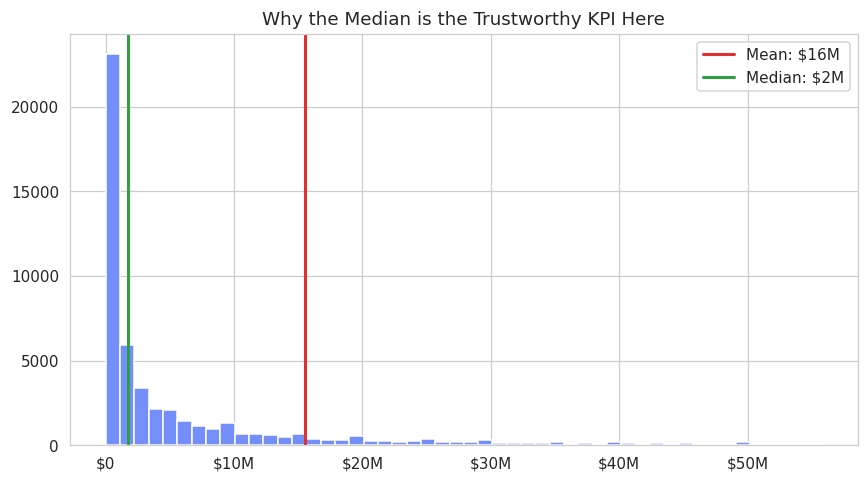

In [1]:
mean_val = df["funding_total_usd"].mean()
median_val = df["funding_total_usd"].median()
fig, ax = plt.subplots(figsize=(8, 4.5))
sample = df["funding_total_usd"].dropna()
ax.hist(sample[sample < sample.quantile(0.95)], bins=50, color="#748FFC")
ax.axvline(mean_val, color="#E03131", linewidth=2, label=f"Mean: {money_fmt(mean_val)}")
ax.axvline(median_val, color="#2F9E44", linewidth=2, label=f"Median: {money_fmt(median_val)}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.set_title("Why the Median is the Trustworthy KPI Here")
ax.legend()
plt.tight_layout()
plt.show()

**What I found:** mean funding sits multiples above median funding, and (notebook 08) the mean's 95% confidence interval is roughly 10x wider in relative terms than the median's bootstrap CI.

**Why it matters:** a board deck or dashboard citing "average funding" without the median overstates what a typical startup raises, and the mean is unstable — sensitive to whichever mega-rounds happen to be in a given time slice or cohort.

**Recommendation:** every funding KPI on the Power BI dashboard and in any executive summary should lead with median, with mean shown as a secondary, clearly-labeled figure — already implemented this way in `powerbi/` per `docs/business_glossary.md`.

---

## Insight 2 — Multi-round fundraising is the strongest lever in the entire dataset

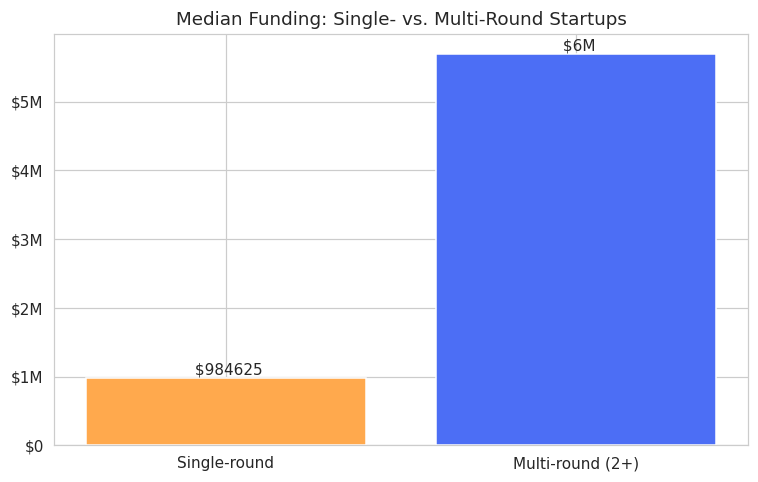

In [1]:
multi_median = df[df["is_multi_round"] == True]["funding_total_usd"].median()
single_median = df[df["is_multi_round"] == False]["funding_total_usd"].median()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["Single-round", "Multi-round (2+)"], [single_median, multi_median], color=["#FFA94D", "#4C6EF5"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.set_title("Median Funding: Single- vs. Multi-Round Startups")
for i, v in enumerate([single_median, multi_median]):
    ax.text(i, v, f" {money_fmt(v)}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**What I found:** across every method used in this project — the notebook 08 regression coefficient (`is_multi_round` = +0.967, the single largest effect, corresponding to ~163% more funding holding other factors constant), notebook 06's mutual information ranking, and notebook 11's permutation importance and SHAP analysis — reaching a second funding round is consistently the strongest identified signal.

**Why it matters:** this is a *reachable milestone*, not a fixed trait like industry or country — a startup can act on this insight far more directly than "be in biotech" or "be based in the US."

**Recommendation:** for a founder-facing product (or an accelerator's advising program), the highest-leverage advice this data supports is: **prioritize whatever it takes to close a second round** — proving initial traction to convert seed/angel money into a Series A-equivalent — over most other observable factors. For a VC's sourcing model, `is_multi_round`/`num_round_types_used` deserve to be weighted heavily in any triage scoring.

---

## Insight 3 — Geographic/industry concentration is real, but the dashboard must carry a coverage caveat

In [1]:
top5_countries = df.groupby("country_name")["funding_total_usd"].sum().sort_values(ascending=False).head(5)
share = top5_countries.sum() / df["funding_total_usd"].sum() * 100
print(f"Top 5 countries capture {share:.1f}% of all disclosed funding in this dataset.")
top5_countries.apply(lambda x: money_fmt(x))

Top 5 countries capture 81.0% of all disclosed funding in this dataset.


country_name
United States     $558B
China              $51B
United Kingdom     $29B
India              $21B
Canada             $16B
Name: funding_total_usd, dtype: str

**What I found:** the top 5 countries capture the large majority of disclosed funding (notebook 05, section 6); this is directionally consistent with real-world venture capital concentration but is **also amplified by known Crunchbase-era data-coverage bias** toward US/English-market company listings.

**Why it matters:** presenting this chart without the coverage caveat risks a stakeholder concluding "non-US startups received almost no funding globally in this era," which overstates what this specific, imperfect data source can support.

**Recommendation:** every geography-ranked visual in the Power BI dashboard carries a footnote citing this coverage limitation (already implemented — see `docs/data_quality_report.md`); this notebook makes that decision's reasoning explicit rather than leaving it as an unexplained dashboard footnote.

---

## Insight 4 — Set realistic expectations for any predictive model built on this data

In [1]:
model_expectations = pd.DataFrame([
    {"model": "Linear regression (interpretable)", "metric": "R-squared", "value": "~0.336", "source": "notebook 08"},
    {"model": "Tree ensemble (predictive)", "metric": "R-squared", "value": "~0.51-0.52", "source": "notebooks 09-10"},
    {"model": "Exit classifier", "metric": "ROC-AUC", "value": "~0.79-0.80", "source": "notebooks 09-10"},
    {"model": "Exit classifier", "metric": "PR-AUC", "value": "well above 0.11 baseline, but well below 1.0", "source": "notebook 10"},
])
model_expectations

,model,metric,value,source
0,Linear regression (interpretable),R-squared,~0.336,notebook 08
1,Tree ensemble (predictive),R-squared,~0.51-0.52,notebooks 09-10
2,Exit classifier,ROC-AUC,~0.79-0.80,notebooks 09-10
3,Exit classifier,PR-AUC,"well above 0.11 baseline, but well below 1.0",notebook 10


**What I found:** even the best model here explains roughly half the variance in funding amount, and the classifier — while clearly better than random — is far from a perfect predictor.

**Why it matters:** funding outcomes are also driven by investor relationships, founder track record, timing, and market sentiment — none of which are observable in structured Crunchbase fields. A stakeholder expecting a model to "solve" startup funding prediction from this data alone would be setting an unrealistic bar.

**Recommendation:** use these models for **ranking and triage** (e.g. "which 200 of these 5,000 startups deserve a closer look"), not for high-stakes automated decisions (e.g. auto-declining a startup). This framing is stated explicitly in the Streamlit app and should travel with the model wherever it's deployed.

---

## Insight 5 — The classifier has a specific, actionable blind spot

**What I found (notebook 11):** the exit classifier under-identifies exits that happened via a lighter funding path (fewer rounds, fewer distinct instrument types) — it's better at recognizing "exits that look like well-funded venture successes" than "exits that happened via an earlier, lighter-funded acquisition."

**Why it matters:** if this model were used for deal-sourcing triage, it would systematically under-prioritize a specific, real category of promising startups — early, capital-efficient companies headed toward an acquisition rather than a long venture-funded path to IPO.

**Recommendation:** don't rely on this classifier alone to *rule out* a startup; pair it with a secondary, qualitative screen for capital-efficient/early-signal companies specifically, since this is a known, named gap rather than random noise.

---

## Insight 6 — Startup segments (clustering) support differentiated engagement, not one-size-fits-all

In [1]:
cluster_ref = pd.read_csv(WH / "cluster_profiles_k5.csv")
cluster_ref[["cluster", "count", "pct_of_dataset", "median_funding", "avg_funding_rounds", "exit_rate", "top_industry"]]

,cluster,count,pct_of_dataset,median_funding,avg_funding_rounds,exit_rate,top_industry
0,0,6001,15.3,1000000.0,1.667,0.084,Apps
1,1,5033,12.9,24100000.0,4.546,0.249,Biotechnology
2,2,13519,34.5,6292200.0,1.565,0.189,Software
3,3,14428,36.9,250000.0,1.214,0.027,Software
4,4,159,0.4,9450000.0,1.346,0.245,Education


**What I found:** the five clusters (notebook 09, production reference) span from a large, young, lightly-funded segment to a small, older, capital-intensive segment — with meaningfully different exit rates across them.

**Why it matters:** a single blanket engagement strategy (e.g. one accelerator program, one investor outreach template) doesn't fit a population this heterogeneous.

**Recommendation:** segment-specific playbooks — e.g. the highest-exit-rate segment likely warrants faster/lighter-touch engagement (they're already succeeding on their own trajectory), while segments with high funding but lower exit rates may benefit more from active operational support.

---

## Business value summary

| Audience | What this project delivers | How to use it |
|---|---|---|
| VC / investor | Exit-likelihood ranking model + segment profiles | Deal-sourcing triage, NOT auto-decline decisions |
| Startup founder | Multi-round-fundraising insight, stage-funnel benchmarks | Fundraising strategy prioritization |
| Market analyst | Star-schema warehouse + Power BI dashboard | Self-serve exploration with documented caveats |
| Data science reviewer | Full audit trail: every bug found, every assumption tested | Evidence of rigor, not just a working demo |

## Interview-ready synthesis

*"What's the single most important business finding?"* — "Multi-round fundraising status is the strongest, most actionable predictor identified across every method used in this project — regression coefficients, mutual information, permutation importance, and SHAP all agree. It's more useful to a founder than any demographic factor because it's something they can act on."

## Next notebook
`13_Conclusion.ipynb` — final wrap-up: limitations, reproducibility statement, and future work.